In [1]:
import os
import gc
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tqdm import tqdm

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, InputLayer
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, log_loss)

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans"})
ACCENT, GREEN = "#7C3AED", "#22C55E"

In [2]:
# ============================================================
# 0  –  Config
# ============================================================
# Same data pipeline and hyperparameters as the frozen final model
# (tuner_results.py). This script does NOT retrain or overwrite that model —
# it only estimates how stable the reported accuracy is across resampled folds.
DATA_DIR        = "features"
SEQUENCE_LENGTH = 30
FEATURES_DIM    = 447
MAX_SAMPLES     = 110
RANDOM_STATE    = 42
BATCH_SIZE      = 32
EPOCHS          = 150

# K=5 -> each fold tests 22 samples/class. Set K=10 to match the paper's
# 11-samples/class test partition exactly (10 full trainings, ~2x the compute).
K = 5

# Best hyperparameters selected by the Hyperband search (see tuner_results.py)
GRU1, GRU2, DROPOUT, L2_RATE, USE_REC_L2, LR = 32, 256, 0.3, 1e-4, False, 1e-3

In [3]:
# ============================================================
# 1  –  Load & balance dataset (un-augmented)
# ============================================================
print("Loading dataset …")
actions = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])
num_classes = len(actions)
label_map = {a: i for i, a in enumerate(actions)}

sequences, labels = [], []
for action in actions:
    action_path = os.path.join(DATA_DIR, action)
    for f in tqdm([f for f in os.listdir(action_path) if f.endswith(".npy")],
                  desc=f"  {action:<15}", leave=False):
        seq = np.load(os.path.join(action_path, f))
        if seq.shape == (SEQUENCE_LENGTH, FEATURES_DIM):
            sequences.append(seq)
            labels.append(label_map[action])

X = np.array(sequences, dtype=np.float32)
y_int = np.array(labels)

# Balance to MAX_SAMPLES per class (first N), same as the frozen run
idx = []
for i in range(num_classes):
    idx.extend(np.where(y_int == i)[0][:MAX_SAMPLES])
X, y_int = X[idx], y_int[idx]
y_oh = to_categorical(y_int, num_classes=num_classes).astype(np.float32)
print(f"  Balanced set: {X.shape[0]} samples across {num_classes} classes "
      f"({MAX_SAMPLES}/class)\n")

Loading dataset …


  Balanced set: 4400 samples across 40 classes (110/class)



In [4]:
# ============================================================
# 2  –  Augmentation (train-only, ×3) — identical to tuner_results.py
# ============================================================
def augment_sequence(data):
    aug = data.copy().astype(np.float32)
    aug += np.random.normal(0, 0.005, aug.shape).astype(np.float32)
    aug = aug.reshape(30, -1, 3)
    aug *= np.float32(np.random.uniform(0.95, 1.05))
    angle = np.radians(np.random.uniform(3, 5) * np.random.choice([-1, 1]))
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
    aug = np.dot(aug, R).reshape(30, FEATURES_DIM)
    new_len = int(30 * np.random.uniform(0.9, 1.1))
    out = np.zeros((30, FEATURES_DIM), dtype=np.float32)
    for f in range(FEATURES_DIM):
        out[:, f] = np.interp(
            np.linspace(0, 29, 30),
            np.linspace(0, 29, new_len),
            np.interp(np.linspace(0, 29, new_len), np.arange(30), aug[:, f]))
    return out

def augment_x3(X_tr, y_tr):
    n = X_tr.shape[0]
    Xa = np.empty((n * 3, SEQUENCE_LENGTH, FEATURES_DIM), dtype=np.float32)
    ya = np.empty((n * 3, y_tr.shape[1]), dtype=np.float32)
    Xa[:n], ya[:n] = X_tr, y_tr
    for i, seq in enumerate(X_tr):
        Xa[n + i] = augment_sequence(seq)
        Xa[2 * n + i] = augment_sequence(seq)
    ya[n:2 * n] = y_tr
    ya[2 * n:3 * n] = y_tr
    perm = np.random.permutation(len(Xa))
    return Xa[perm], ya[perm]

In [5]:
# ============================================================
# 3  –  Model builder — fixed best hyperparameters
# ============================================================
def build_model():
    kreg = regularizers.l2(L2_RATE)
    rreg = regularizers.l2(L2_RATE) if USE_REC_L2 else None
    model = Sequential([
        InputLayer(input_shape=(SEQUENCE_LENGTH, FEATURES_DIM)),
        GRU(GRU1, return_sequences=True, name="gru_1",
            kernel_regularizer=kreg, recurrent_regularizer=rreg),
        Dropout(DROPOUT, name="dropout_1"),
        GRU(GRU2, return_sequences=False, name="gru_2",
            kernel_regularizer=kreg, recurrent_regularizer=rreg),
        Dropout(DROPOUT, name="dropout_2"),
        Dense(num_classes, activation="softmax", name="output",
              kernel_regularizer=regularizers.l2(L2_RATE)),
    ], name="SignLingo_GRU_KFold")
    model.compile(optimizer=Adam(LR),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [6]:
# ============================================================
# 4  –  Stratified K-fold cross-validation
# ============================================================
# Each fold: hold out 1/K as test, carve a small stratified validation set from
# the rest for early stopping, augment the remaining training data x3, train a
# fresh model, then score the untouched held-out fold.
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_int), start=1):
    print(f"\n{'='*60}\nFOLD {fold}/{K}\n{'='*60}")
    X_te, y_te = X[test_idx], y_oh[test_idx]

    # nested validation split (~10% of the whole set) for early stopping
    X_trf, y_trf = X[train_idx], y_oh[train_idx]
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_trf, y_trf, test_size=0.125, stratify=y_int[train_idx],
        random_state=RANDOM_STATE)

    X_tr, y_tr = augment_x3(X_tr, y_tr)
    print(f"  train(aug)={len(X_tr)}  val={len(X_val)}  test={len(X_te)}")

    tf.keras.backend.clear_session()
    model = build_model()
    model.fit(
        tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
          .shuffle(len(X_tr)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
        validation_data=tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE),
        epochs=EPOCHS,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=15,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                              patience=5, min_lr=1e-6, verbose=0),
        ],
        verbose=0,
    )

    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    y_true = y_te.argmax(axis=1)
    row = {
        "fold": fold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "loss": log_loss(y_true, probs, labels=list(range(num_classes))),
    }
    fold_rows.append(row)
    print(f"  acc={row['accuracy']*100:.2f}%  f1={row['f1']:.4f}  "
          f"CE-loss={row['loss']:.4f}")

    del model, X_tr, y_tr, X_val, y_val, X_te, y_te, probs
    gc.collect()


FOLD 1/5
  train(aug)=9240  val=440  test=880

  acc=99.20%  f1=0.9921  CE-loss=0.0377

FOLD 2/5
  train(aug)=9240  val=440  test=880
  acc=98.75%  f1=0.9875  CE-loss=0.0430

FOLD 3/5
  train(aug)=9240  val=440  test=880
  acc=99.55%  f1=0.9955  CE-loss=0.0281

FOLD 4/5
  train(aug)=9240  val=440  test=880
  acc=99.20%  f1=0.9921  CE-loss=0.0311

FOLD 5/5
  train(aug)=9240  val=440  test=880
  acc=99.09%  f1=0.9909  CE-loss=0.0282


In [7]:
# ============================================================
# 5  –  Aggregate results (mean +/- std)
# ============================================================
def mean_std(key):
    v = np.array([r[key] for r in fold_rows])
    return v.mean(), v.std()

print(f"\n{'='*60}\n{K}-FOLD SUMMARY\n{'='*60}")
summary = {}
for key in ["accuracy", "precision", "recall", "f1", "loss"]:
    m, sd = mean_std(key)
    summary[key] = {"mean": float(m), "std": float(sd)}
    unit = "%" if key != "loss" else ""
    scale = 100 if key != "loss" else 1
    print(f"  {key:10s}: {m*scale:.4f}{unit}  +/- {sd*scale:.4f}{unit}")

results = {"k": K, "folds": fold_rows, "summary": summary}
with open("kfold_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved -> kfold_results.json")


5-FOLD SUMMARY
  accuracy  : 99.1591%  +/- 0.2551%
  precision : 99.2066%  +/- 0.2427%
  recall    : 99.1591%  +/- 0.2551%
  f1        : 99.1607%  +/- 0.2568%
  loss      : 0.0336  +/- 0.0059

Saved -> kfold_results.json


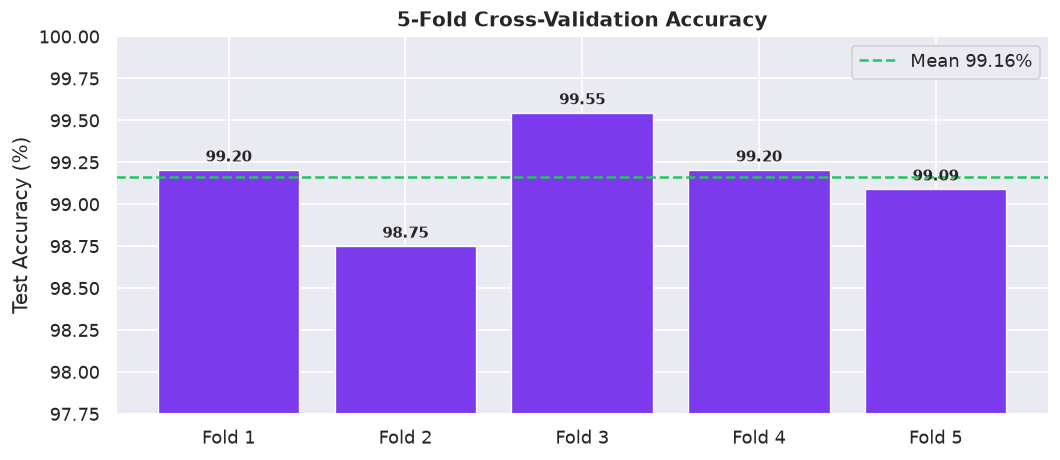

In [8]:
# ============================================================
# 6  –  Per-fold accuracy chart
# ============================================================
accs = [r["accuracy"] * 100 for r in fold_rows]
m_acc = np.mean(accs)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([f"Fold {r['fold']}" for r in fold_rows], accs,
              color=ACCENT, edgecolor="white", linewidth=0.8)
ax.axhline(m_acc, color=GREEN, lw=1.5, linestyle="--",
           label=f"Mean {m_acc:.2f}%")
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(min(accs) - 1, min(100, max(accs) + 1))
ax.set_ylabel("Test Accuracy (%)")
ax.set_title(f"{K}-Fold Cross-Validation Accuracy", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()